# LeetCode #154: Find Minimum in Rotated Sorted Array II

https://leetcode.com/problems/find-minimum-in-rotated-sorted-array-ii/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (linear scan)** | $O(n)$ | $O(1)$ |
| **Optimal: Binary Search with Duplicate Shrinking ★** | $O(n)$ worst, $O(\log n)$ avg | $O(1)$ |

---

## Understanding the Methods

### Brute Force (linear scan)
Scan every element tracking the minimum. Always $O(n)$; ignores the sorted structure.

### Optimal: Binary Search with Duplicate Shrinking ★
Extension of #153's pivot approach. When `nums[mid] > nums[hi]` the minimum is right of mid. When `nums[mid] < nums[hi]` the minimum is at mid or left. When `nums[mid] == nums[hi]` we cannot determine the side — safely do `hi--` to shrink by one without losing the minimum (since `nums[hi]` equals `nums[mid]`, any candidate at `hi` is replicated at `mid` or earlier).

**Constraints:**
* n == nums.length
* 1 <= n <= 5000
* -5000 <= nums[i] <= 5000
* nums is sorted and rotated (may contain duplicates)


## Solutions

### C#

In [ ]:
public int FindMin(int[] nums) {
    int lo = 0, hi = nums.Length - 1;
    while (lo < hi) {
        int mid = lo + (hi - lo) / 2;
        if (nums[mid] > nums[hi]) lo = mid + 1;  // Minimum is right of mid
        else if (nums[mid] < nums[hi]) hi = mid;  // Minimum is at mid or left
        else hi--;  // Can't tell — shrink right boundary safely
    }
    return nums[lo];
}


### Python

In [ ]:
def findMin(self, nums: list[int]) -> int:
    lo, hi = 0, len(nums) - 1
    while lo < hi:
        mid = lo + (hi - lo) // 2
        if nums[mid] > nums[hi]:
            lo = mid + 1   # Minimum is right of mid
        elif nums[mid] < nums[hi]:
            hi = mid       # Minimum is at mid or left
        else:
            hi -= 1        # Can't tell — shrink right boundary safely
    return nums[lo]


### Go

In [ ]:
func findMin(nums []int) int {
    lo, hi := 0, len(nums)-1
    for lo < hi {
        mid := lo + (hi-lo)/2
        if nums[mid] > nums[hi] {
            lo = mid + 1  // Minimum is right of mid
        } else if nums[mid] < nums[hi] {
            hi = mid      // Minimum is at mid or left
        } else {
            hi--          // Can't tell — shrink right boundary safely
        }
    }
    return nums[lo]
}


### Rust

In [ ]:
pub fn find_min(nums: Vec<i32>) -> i32 {
    let (mut lo, mut hi) = (0usize, nums.len() - 1);
    while lo < hi {
        let mid = lo + (hi - lo) / 2;
        if nums[mid] > nums[hi] {
            lo = mid + 1;  // Minimum is right of mid
        } else if nums[mid] < nums[hi] {
            hi = mid;      // Minimum is at mid or left
        } else {
            hi -= 1;       // Can't tell — shrink right boundary safely
        }
    }
    nums[lo]
}


## Example Scenarios

**1. Common Case**
**Input:** nums = [2, 2, 2, 0, 1]
mid=2(2)==nums[hi]=1? No, 2>1 → lo=3. mid=3(0)<1 → hi=3. lo=hi=3 → return 0.

**2. Slightly Complex**
**Input:** nums = [3, 3, 1, 3]
mid=1(3)==nums[hi]=3 → hi--=2. mid=1(3)>nums[hi]=1 → lo=2. lo=hi=2 → return nums[2]=1.

**3. Edge Case: Time Factor**
**Input:** nums = [1, 1, 1, ..., 1, 0, 1] (4998 ones, then 0, then 1)
Every step hits nums[mid]==nums[hi]=1 → hi-- until hi reaches 4998. This is the $O(n)$ worst case: uniform duplicates force linear shrinking to uncover the minimum.

**4. Edge Case: Space Factor**
**Input:** nums = [0]
lo=hi=0, loop never enters, return nums[0]=0. Uses $O(1)$ space: three integer variables (lo, hi, mid).

**5. Almost-Impossible but Plausible**
**Input:** nums = [2, 2, 2, 2, 2, 2, 2] (all same)
Every iteration: nums[mid]==nums[hi] → hi--. Loop takes $n-1$ steps, returning nums[0]=2. Functionally $O(n)$ but correct — hi-- never discards the minimum since `nums[hi]` equals the duplicate at `mid` which is also ≥ minimum.


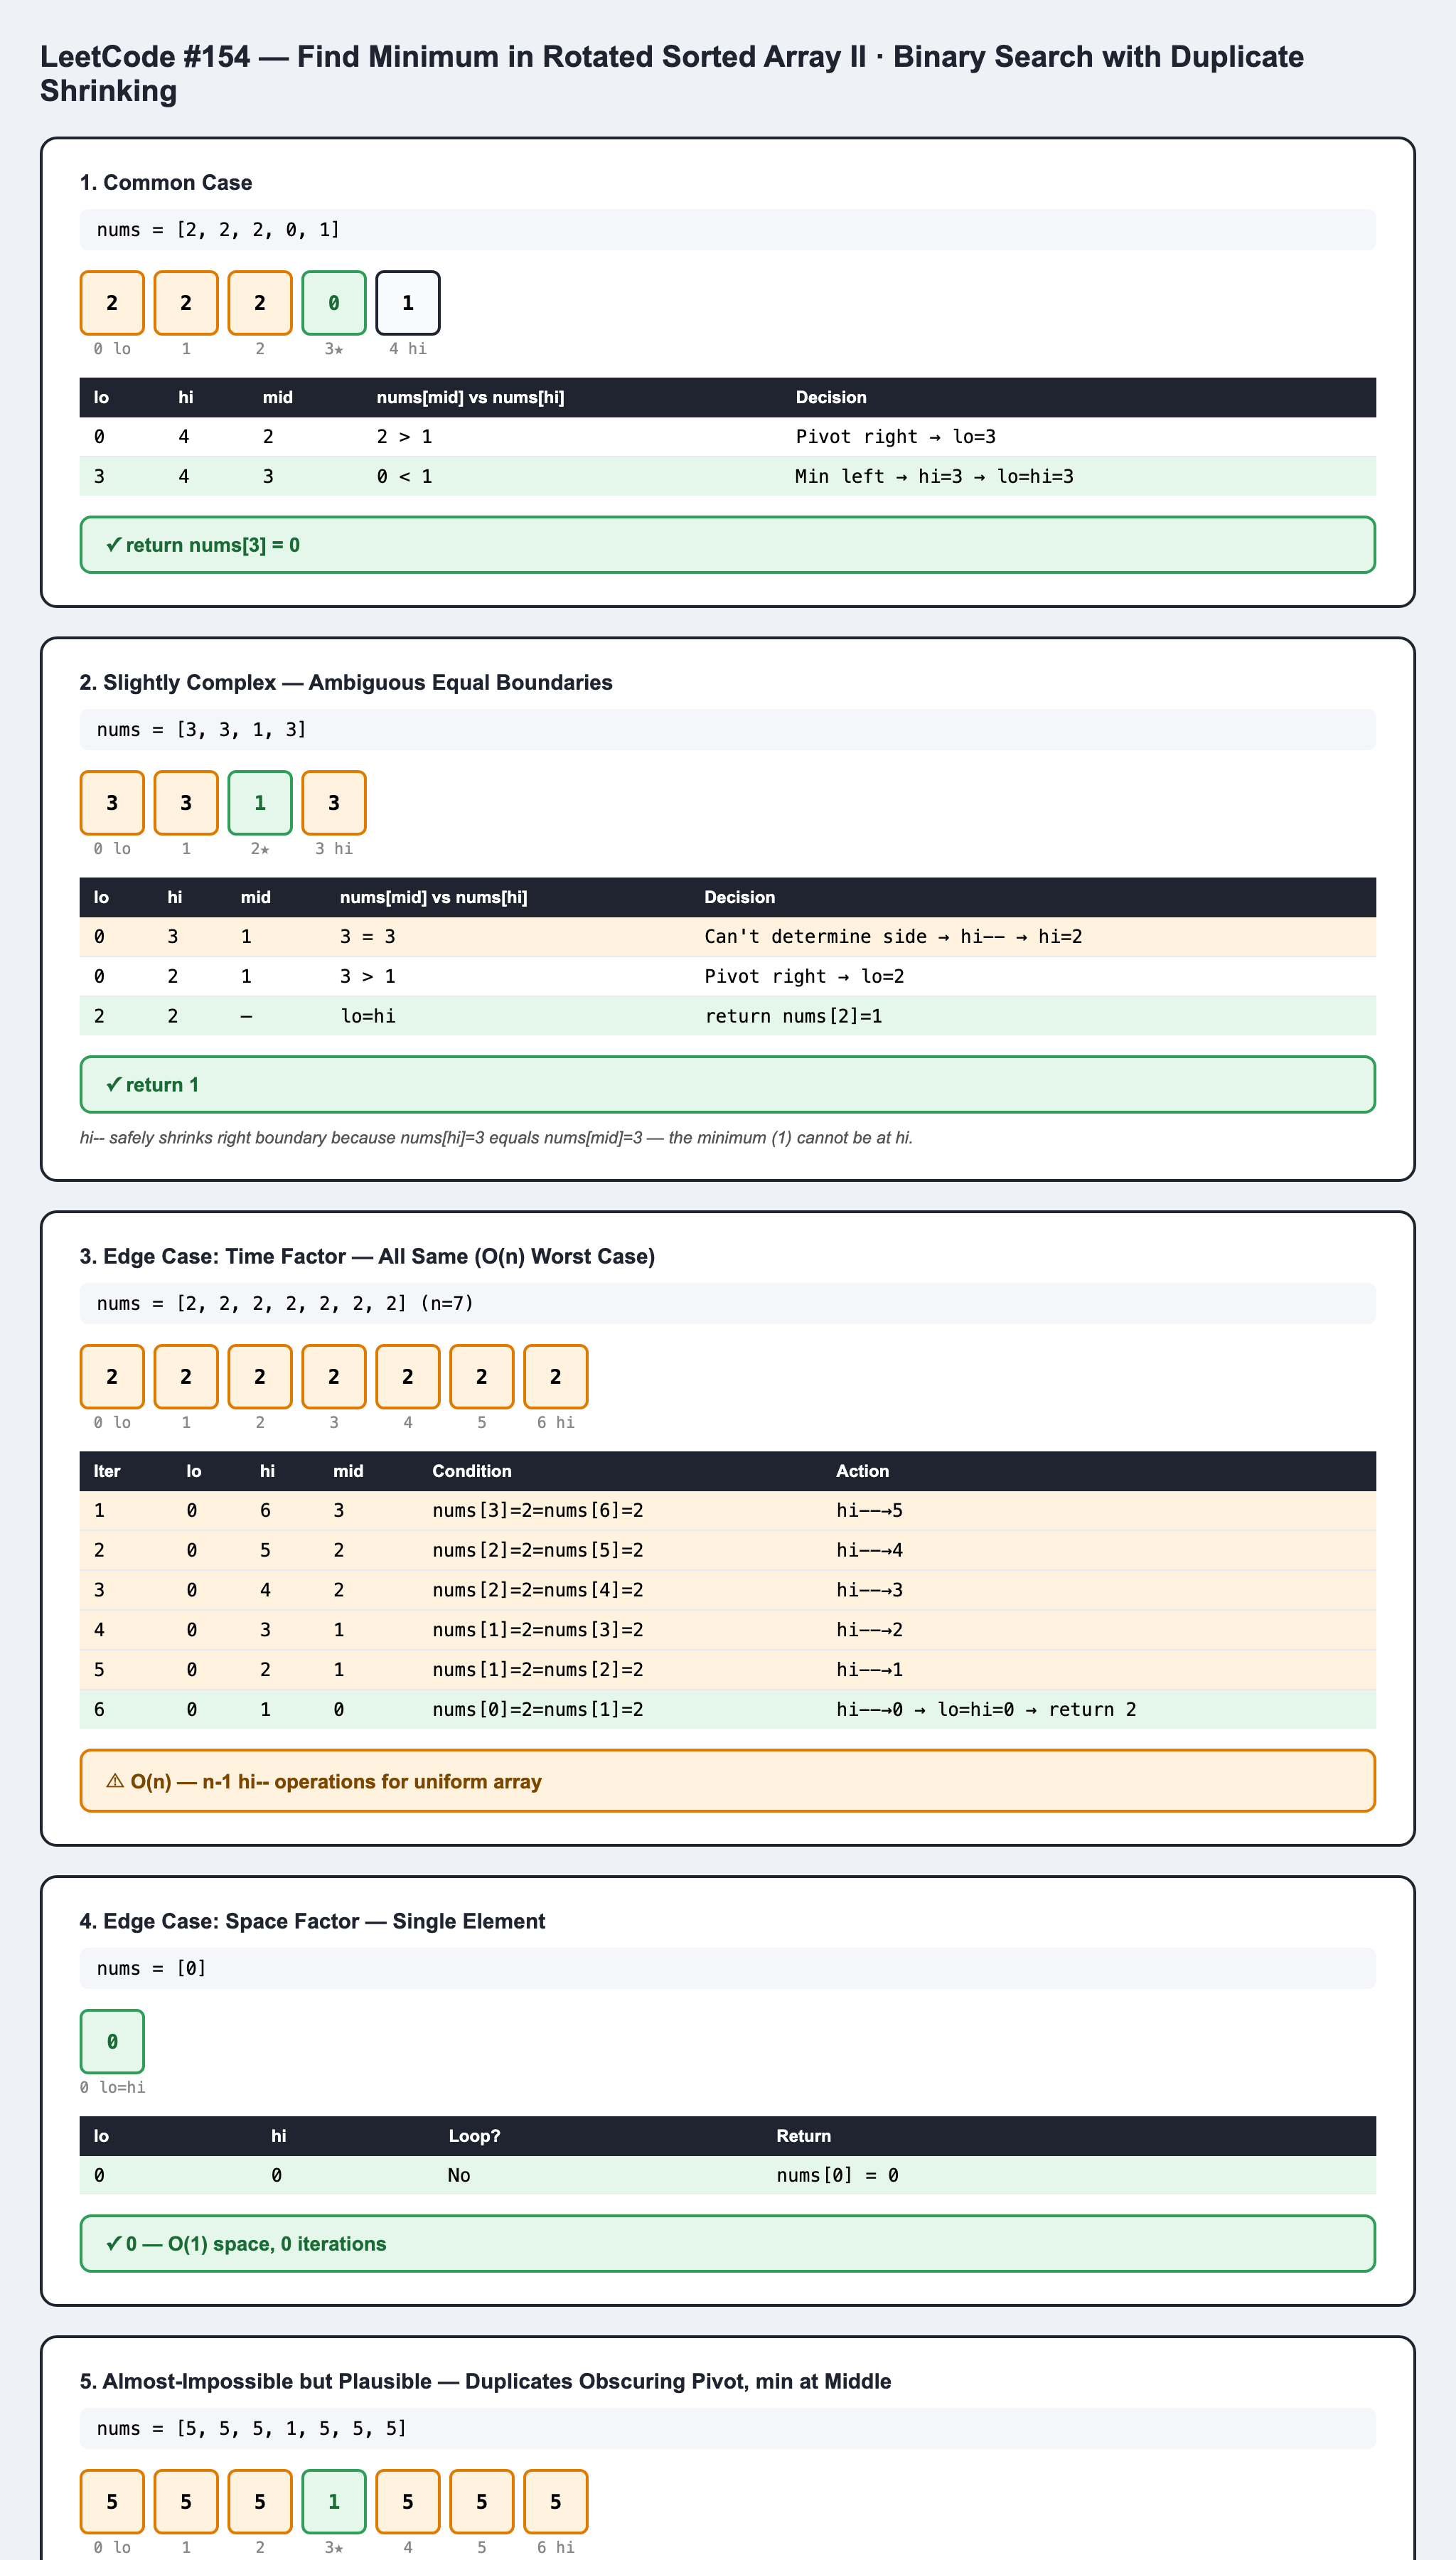